In [ ]:
import ee

ee.Initialize(project="pklot-termposter")  # substitui pelo teu Project ID
print("OK!")

OK!


Imagens encontradas: 7
  Baixando 2010-07-01...
    ✅ Salvo: /Users/felipe/Downloads/walmart_test/walmart_teste_2010-07-01.png
  Baixando 2012-06-08...
    ✅ Salvo: /Users/felipe/Downloads/walmart_test/walmart_teste_2012-06-08.png
  Baixando 2014-07-04...
    ✅ Salvo: /Users/felipe/Downloads/walmart_test/walmart_teste_2014-07-04.png
  Baixando 2016-06-22...
    ✅ Salvo: /Users/felipe/Downloads/walmart_test/walmart_teste_2016-06-22.png
  Baixando 2018-09-22...
    ✅ Salvo: /Users/felipe/Downloads/walmart_test/walmart_teste_2018-09-22.png
  Baixando 2020-06-07...
    ✅ Salvo: /Users/felipe/Downloads/walmart_test/walmart_teste_2020-06-07.png
  2022-06-29 - já existe, pulando

Concluído!


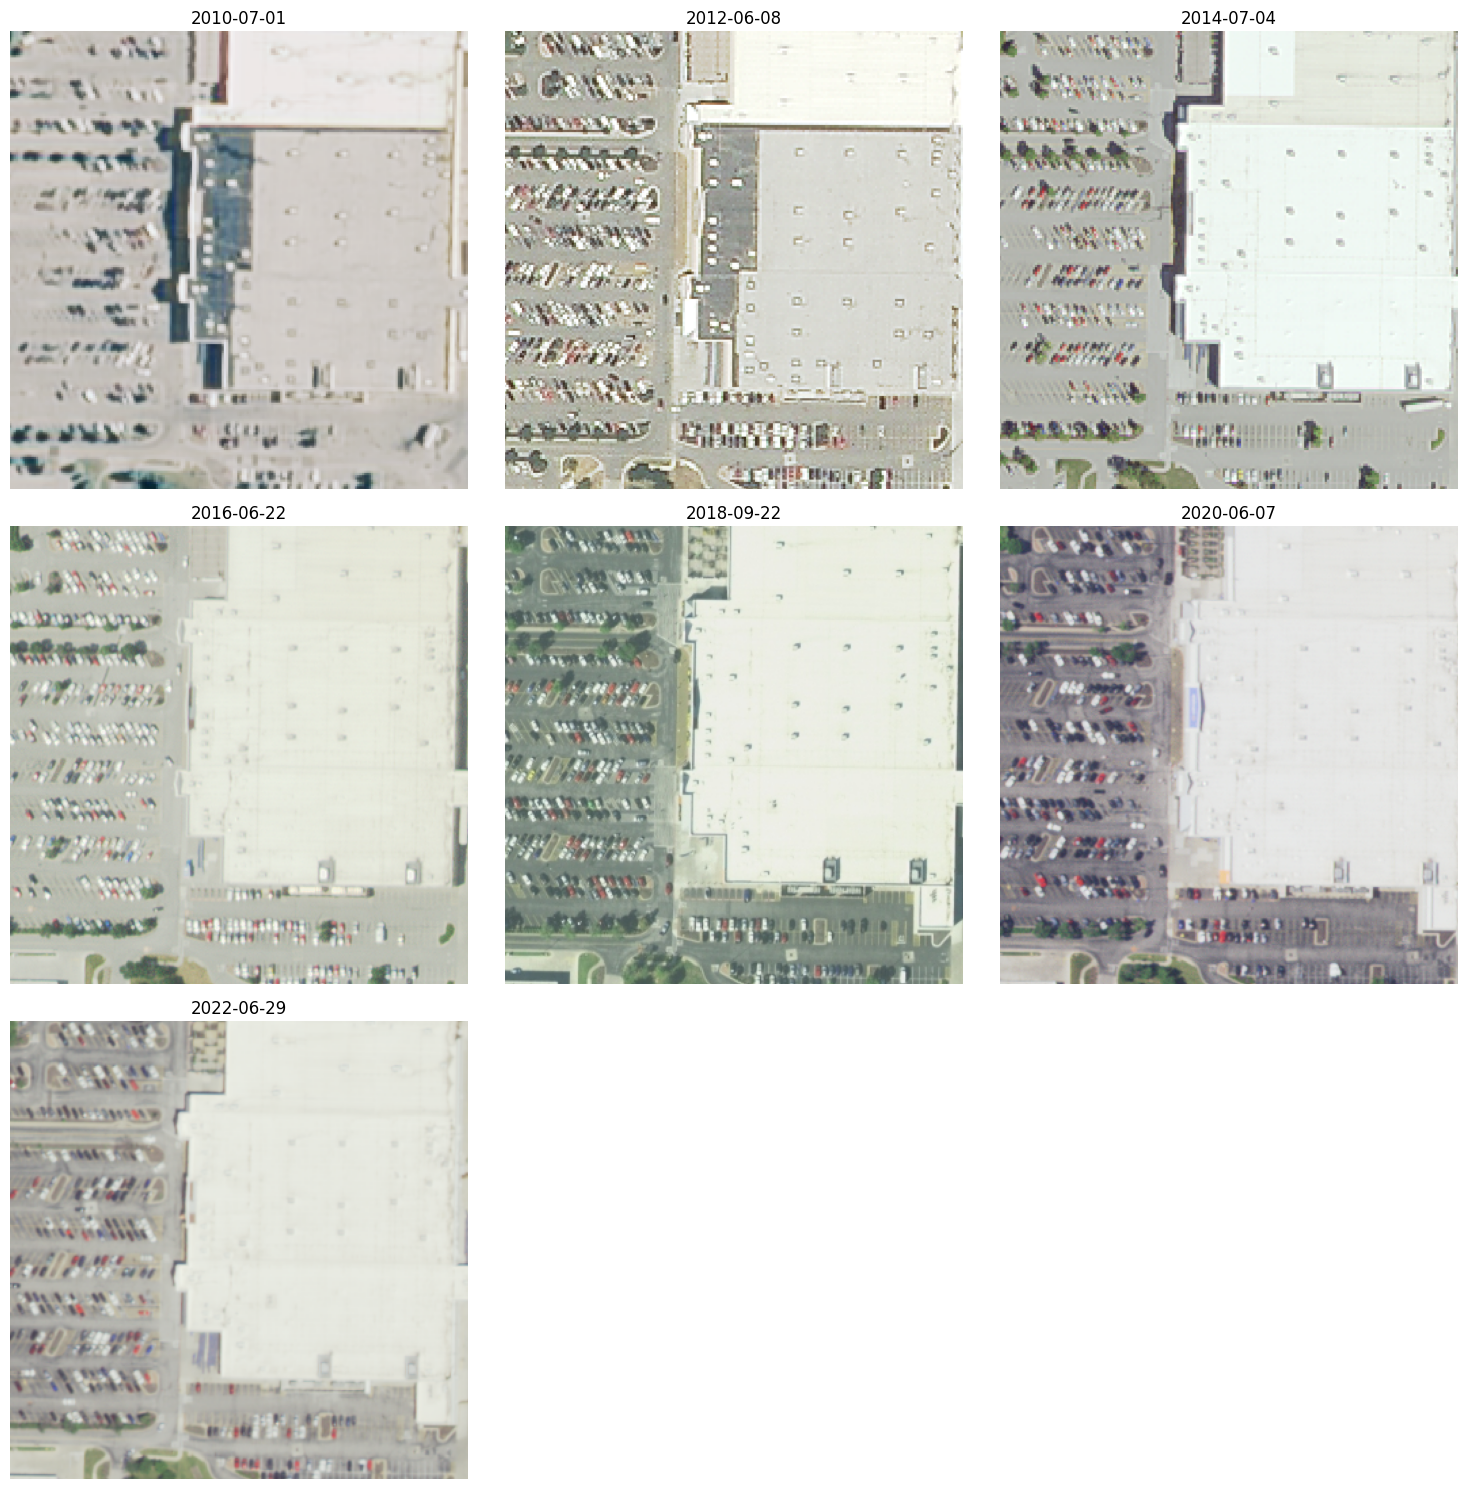

In [ ]:
import ee
import requests
import os
from PIL import Image
import matplotlib.pyplot as plt

# Inicializar
ee.Initialize(project="pklot-termposter")  # 👈 teu Project ID

# ============================================
# CONFIGURAÇÃO - edita aqui
# ============================================
OUTPUT_DIR = "/Users/felipe/Downloads/walmart_test"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Local de teste
LAT = 39.2429
LON = -94.4610
NAME = "walmart_teste"

# Data inicial de busca (formato YYYY-MM-DD)
START_DATE = "2010-01-01"  # busca desde essa data até hoje

# ============================================
# BUSCAR TODAS AS IMAGENS DISPONÍVEIS
# ============================================
point = ee.Geometry.Point([LON, LAT])
region = point.buffer(100).bounds()  # ~200m x 200m

collection = ee.ImageCollection("USDA/NAIP/DOQQ") \
    .filterBounds(point) \
    .filterDate(START_DATE, "2026-01-01") \
    .sort("system:time_start")

n = collection.size().getInfo()
print(f"Imagens encontradas: {n}")

if n == 0:
    print("Nenhuma imagem encontrada para essa data/local.")
else:
    images_list = collection.toList(n)

    for i in range(n):
        img = ee.Image(images_list.get(i))
        date = img.date().format("YYYY-MM-dd").getInfo()

        out_path = os.path.join(OUTPUT_DIR, f"{NAME}_{date}.png")

        if os.path.exists(out_path):
            print(f"  {date} - já existe, pulando")
            continue

        print(f"  Baixando {date}...")

        url = img.select(["R", "G", "B"]).getThumbURL({
            "region": region,
            "dimensions": "1024x1024",
            "format": "png"
        })

        response = requests.get(url)

        if response.status_code == 200:
            with open(out_path, "wb") as f:
                f.write(response.content)
            print(f"    ✅ Salvo: {out_path}")
        else:
            print(f"    ❌ Erro {response.status_code}: {response.text[:200]}")

print("\nConcluído!")

# ============================================
# MOSTRAR TODAS AS IMAGENS BAIXADAS
# ============================================
saved_files = sorted([
    f for f in os.listdir(OUTPUT_DIR)
    if f.startswith(NAME) and f.endswith(".png")
])

if saved_files:
    n_imgs = len(saved_files)
    cols = 3
    rows = (n_imgs + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten() if n_imgs > 1 else [axes]

    for ax, fname in zip(axes, saved_files):
        img_display = Image.open(os.path.join(OUTPUT_DIR, fname))
        ax.imshow(img_display)
        ax.set_title(fname.replace(f"{NAME}_", "").replace(".png", ""))
        ax.axis("off")

    # Esconde eixos extras
    for ax in axes[len(saved_files):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()